In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
nav = pd.read_csv(
    'C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\02_nav_history.csv'
)

txn = pd.read_csv(
    'C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\08_investor_transactions.csv'
)

print(nav.shape)
print(txn.shape)

(46000, 3)
(32778, 13)


In [8]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [9]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [10]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [11]:
var_cvar = (
    nav.groupby('amfi_code')['daily_return']
       .apply(
           lambda x: pd.Series({
               'VaR_95': np.percentile(
                   x.dropna(), 5
               ),
               'CVaR_95': x[
                   x <= np.percentile(
                       x.dropna(), 5
                   )
               ].mean()
           })
       )
       .unstack()
)

var_cvar.head()

,VaR_95,CVaR_95
amfi_code,,
100016,-0.014364,-0.018060
100025,-0.003793,-0.004994
100033,-0.019034,-0.023456
101206,-0.013282,-0.017439
101207,-0.026021,-0.032459


In [12]:
var_cvar.to_csv(
    'var_cvar_report.csv'
)

print(
    "Saved Successfully"
)

Saved Successfully


In [13]:
var_cvar.sort_values(
    'VaR_95'
).head(10)

,VaR_95,CVaR_95
amfi_code,,
119599,-0.026859,-0.032384
119095,-0.026188,-0.031667
101207,-0.026021,-0.032459
118634,-0.025438,-0.032304
119598,-0.024507,-0.030595
149324,-0.023483,-0.031036
102886,-0.019220,-0.023251
100033,-0.019034,-0.023456
120505,-0.018892,-0.024342


In [14]:
nav['amfi_code'].nunique()

40

In [15]:
nav['amfi_code'].unique()[:10]

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [16]:
key_funds = [
    100016,
    100025,
    100033,
    101206,
    101207
]

In [17]:
nav['rolling_sharpe'] = (
    nav.groupby('amfi_code')['daily_return']
       .transform(
           lambda x:
           (x.rolling(90).mean() /
            x.rolling(90).std())
           * np.sqrt(252)
       )
)

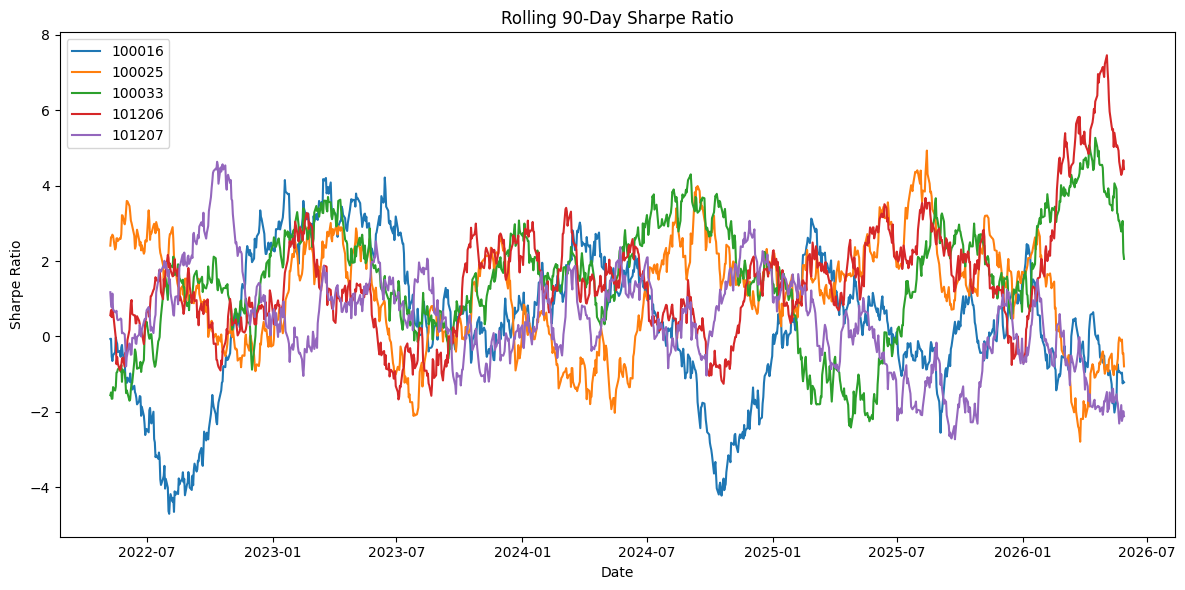

In [18]:
plt.figure(figsize=(12,6))

for fund in key_funds:
    temp = nav[
        nav['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.tight_layout()

plt.savefig(
    'rolling_sharpe_chart.png'
)

plt.show()

In [19]:
import os

print(
    os.path.exists(
        'rolling_sharpe_chart.png'
    )
)

True


In [20]:
print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [21]:
txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

txn['cohort_year'] = (
    txn.groupby('investor_id')
       ['transaction_date']
       .transform('min')
       .dt.year
)

txn[['investor_id','cohort_year']].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [22]:
avg_investment = (
    txn.groupby('cohort_year')
       ['amount_inr']
       .mean()
       .reset_index()
)

avg_investment

,cohort_year,amount_inr
0,2024,107422.541832
1,2025,109158.577061


In [23]:
total_invested = (
    txn.groupby('cohort_year')
       ['amount_inr']
       .sum()
       .reset_index()
)

total_invested

,cohort_year,amount_inr
0,2024,3491125187
1,2025,30455243


In [24]:
top_fund = (
    txn.groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund.sort_values(
        ['cohort_year','count'],
        ascending=[True,False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [25]:
cohort_report = (
    avg_investment
    .merge(
        total_invested,
        on='cohort_year'
    )
)

cohort_report.columns = [
    'cohort_year',
    'avg_investment',
    'total_invested'
]

cohort_report

,cohort_year,avg_investment,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


    ### Investor Cohort Analysis

Investors who entered in 2024 contributed the overwhelming majority of investment volume, with total investments exceeding ₹3.49 billion. Although the 2025 cohort shows a slightly higher average investment amount per transaction, its overall contribution remains relatively small due to fewer investors. Fund preference also varies by cohort, with AMFI code 148568 being most popular among 2024 investors and AMFI code 119599 leading among 2025 investors.


In [26]:
sip = txn[
    txn['transaction_type'] == 'SIP'
].copy()

print(sip.shape)

(19716, 14)


In [27]:
sip_counts = (
    sip.groupby('investor_id')
       .size()
)

eligible = sip_counts[
    sip_counts >= 6
].index

sip = sip[
    sip['investor_id']
      .isin(eligible)
]

print(
    "Eligible Investors:",
    sip['investor_id'].nunique()
)

Eligible Investors: 1362


In [28]:
sip = sip.sort_values(
    ['investor_id',
     'transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')
       ['transaction_date']
       .diff()
       .dt.days
)

avg_gap = (
    sip.groupby('investor_id')
       ['gap_days']
       .mean()
       .reset_index()
)

avg_gap.head()

,investor_id,gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [29]:
avg_gap['status'] = np.where(
    avg_gap['gap_days'] > 35,
    'At-Risk',
    'Active'
)

avg_gap['status'].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [30]:
avg_gap['status'].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [31]:
continuity_rate = (
    30 / (1332 + 30)
) * 100

print(
    f"SIP Continuity Rate: {continuity_rate:.2f}%"
)

SIP Continuity Rate: 2.20%


### SIP Continuity Analysis

Among investors with at least six SIP transactions, only 30 investors maintained an average contribution gap of 35 days or less. A total of 1,332 investors were classified as at-risk due to longer contribution intervals. The overall SIP continuity rate is approximately 2.2%, indicating significant opportunities for investor engagement and retention initiatives.


In [32]:
fund_master = pd.read_csv('C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\01_fund_master.csv')
scheme_perf = pd.read_csv('C:\\Users\\ABHILASH\mutual_fund_project\\data\\raw\\07_scheme_performance.csv')

print(fund_master.columns)
print("\n")
print(scheme_perf.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ABHILASH\AppData\Local\Temp\ipykernel_27476\2286124091.py:2: SyntaxWarning: invalid escape sequence '\m'
  scheme_perf = pd.read_csv('C:\\Users\\ABHILASH\mutual_fund_project\\data\\raw\\07_scheme_performance.csv')


In [33]:
funds = fund_master.merge(
    scheme_perf,
    on='amfi_code',
    how='inner'
)

print(funds.shape)

(40, 33)


In [34]:
funds['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [35]:
def recommend_funds(risk_appetite):
    ...

In [36]:
funds['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [37]:
import pandas as pd

# Merge data
funds = fund_master.merge(
    scheme_perf,
    on='amfi_code',
    how='inner'
)

# Recommender Function
def recommend_funds(risk_appetite):

    filtered = funds[
        funds['risk_grade']
        .str.lower()
        .str.strip()
        == risk_appetite.lower()
    ]

    recommendations = (
        filtered.sort_values(
            'sharpe_ratio',
            ascending=False
        )[
            [
                'scheme_name',
                'fund_house',
                'risk_grade',
                'sharpe_ratio',
                'return_3yr_pct'
            ]
        ]
        .head(3)
    )

    return recommendations


# Example Usage
print("\nLOW RISK FUNDS")
print(recommend_funds('Low'))

print("\nMODERATE RISK FUNDS")
print(recommend_funds('Moderate'))

print("\nHIGH RISK FUNDS")
print(recommend_funds('High'))


# Save Deliverable
recommender_code = """
import pandas as pd

def recommend_funds(risk_appetite, funds):

    filtered = funds[
        funds['risk_grade']
        .str.lower()
        .str.strip()
        == risk_appetite.lower()
    ]

    recommendations = (
        filtered.sort_values(
            'sharpe_ratio',
            ascending=False
        )[
            [
                'scheme_name',
                'fund_house',
                'risk_grade',
                'sharpe_ratio',
                'return_3yr_pct'
            ]
        ]
        .head(3)
    )

    return recommendations
"""

with open(
    'recommender.py',
    'w',
    encoding='utf-8'
) as f:
    f.write(recommender_code)

print("recommender.py created successfully")


LOW RISK FUNDS


KeyError: "['scheme_name', 'fund_house'] not in index"

In [38]:
holdings = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\09_portfolio_holdings.csv")

In [39]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [ ]:
import pandas as pd
hhi_report = (
    holdings.groupby('amfi_code')['weight_pct']
    .apply(lambda x: ((x/100)**2).sum())
    .reset_index(name='HHI')
)

hhi_report = hhi_report.sort_values(
    'HHI',
    ascending=False
)

print(hhi_report.head(10))

hhi_report.to_csv(
    "sector_hhi_report.csv",
    index=False
)


    amfi_code       HHI
11     119092  0.206448
3      101207  0.200700
18     119599  0.174751
4      102885  0.174709
7      118632  0.168298
29     148568  0.167930
21     120505  0.157570
22     120506  0.153794
27     125498  0.152414
23     120841  0.149680
category
Diversified                25
Moderately Concentrated     9
Name: count, dtype: int64


In [47]:
print(hhi_report.head(10))
print(hhi_report['category'].value_counts())

    amfi_code       HHI                 category
11     119092  0.206448  Moderately Concentrated
3      101207  0.200700  Moderately Concentrated
18     119599  0.174751  Moderately Concentrated
4      102885  0.174709  Moderately Concentrated
7      118632  0.168298  Moderately Concentrated
29     148568  0.167930  Moderately Concentrated
21     120505  0.157570  Moderately Concentrated
22     120506  0.153794  Moderately Concentrated
27     125498  0.152414  Moderately Concentrated
23     120841  0.149680              Diversified
category
Diversified                25
Moderately Concentrated     9
Name: count, dtype: int64
